# Main notebook

### Init

In [1]:
# git add .
# git commit -m "message"
# git push origin main


%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd
import numpy as np
import torch
import deepchem as dc
import matplotlib.pyplot as plt

from src.data.dataMol import load_data, print_mol_types, featurize
from src.data.preprocess import keep_largest, salt_remover, preprocess, preprocess_conc
from src.utils.plotting import plot_smiles, plot_metals, plot_training


from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem import AllChem, Draw, PandasTools, Descriptors
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
from rdkit.Chem.Draw import IPythonConsole

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
/home/vollmers/.conda/envs/gnn-m/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipped loading modules with transformers dependency. 

# Init Data

## Moldata

In [2]:
path = Path("Data") / "toxicity_fish.csv"
selected_columns = ["SMILES", "conc"]
cut = 10000
# cut = None

df = load_data(path, selected_columns, cut)

print(df.head())
print("")
print_mol_types(df)

       SMILES  conc
0  O=[O+][O-]  0.18
1  O=[O+][O-]  0.18
2  O=[O+][O-]  0.26
3  O=[O+][O-]  0.26
4  O=[O+][O-]  0.17



[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not removing hydrogen atom without neighbors
[13:20:24] WARNING: not r

Total molecules: 10000
Unique molecules: 2738
Salts: 3023, 30.23%
Single atoms: 62, 0.62%
Metals: 3098, 30.98%


### Data analysis

       SMILES  conc
0  O=[O+][O-]  0.18
1  O=[O+][O-]  0.18
2  O=[O+][O-]  0.26
3  O=[O+][O-]  0.26
4  O=[O+][O-]  0.17


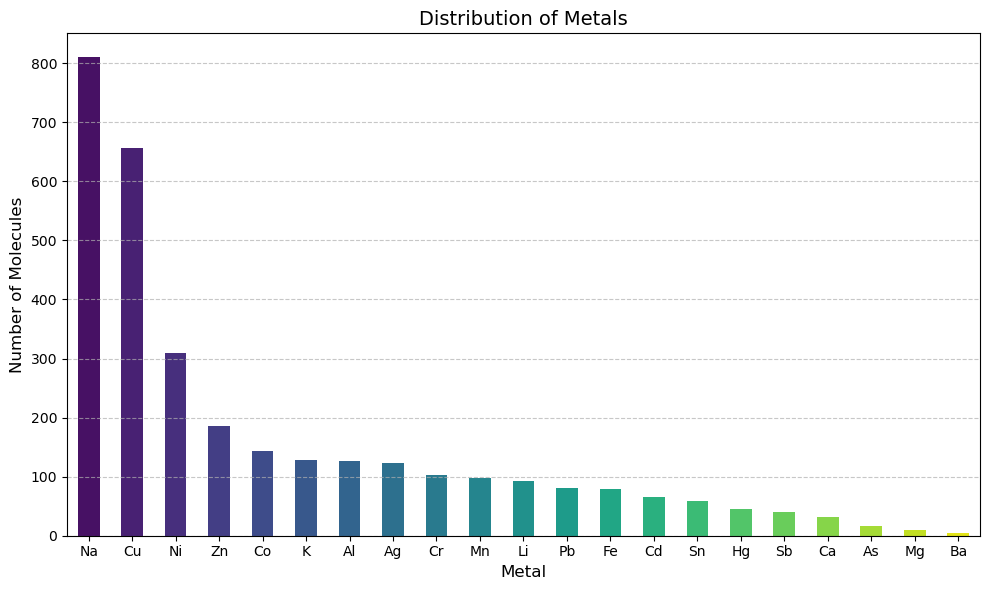

In [3]:
# Mol types and metals

mol_id = 16
print(df.head())

plot_metals(df)

### Data processing

In [4]:
# Preprocess by splitting salts, removing lone atoms and removing metals, also converting concentrations to log scale
df = preprocess(df, split_salts=True, remove_lone=True, remove_metals=False)

print(df.head())
print("")
print_mol_types(df)

[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not removing hydrogen atom without neighbors
[13:20:27] WARNING: not r

       SMILES  conc    log10c
0  O=[O+][O-]  0.18 -0.744727
1  O=[O+][O-]  0.18 -0.744727
2  O=[O+][O-]  0.26 -0.585027
3  O=[O+][O-]  0.26 -0.585027
4  O=[O+][O-]  0.17 -0.769551

Total molecules: 9936
Unique molecules: 2592
Salts: 0, 0.00%
Single atoms: 0, 0.00%
Metals: 1698, 17.09%


### PyG

In [5]:
from torch_geometric.utils.smiles import from_smiles

# Featurize the data
df["features"] = df["SMILES"].apply(lambda x: from_smiles(x))

print(df["features"][0])
print("")
print(df.head())
print("")
print(f"Length of dataset: {len(df)}")

Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]')

       SMILES  conc    log10c  \
0  O=[O+][O-]  0.18 -0.744727   
1  O=[O+][O-]  0.18 -0.744727   
2  O=[O+][O-]  0.26 -0.585027   
3  O=[O+][O-]  0.26 -0.585027   
4  O=[O+][O-]  0.17 -0.769551   

                                            features  
0  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
1  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
2  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
3  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
4  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  

Length of dataset: 9936


In [6]:
print(from_smiles("[NH4+]").edge_index)
print(len(from_smiles("[NH4+]").edge_index[0]))
print(from_smiles("[NH4+]").edge_index.numel())

print(from_smiles("O=[O+][O-]").edge_index)
print(len(from_smiles("O=[O+][O-]").edge_index[0]))
print(from_smiles("O=[O+][O-]").edge_index.numel())


tensor([], size=(2, 0), dtype=torch.int64)
0
0
tensor([[0, 1, 1, 2],
        [1, 0, 2, 1]])
4
8


## Metadata

In [7]:
from src.data.dataMeta import encode_taxonomy

# all taxonomy features: "taxid", "superkingdom", "kingdom", "phylum", "subphylum", "class", "order", "family", "genus"
# selected taxonomy features for embedding, value is embedding_dim
embedding_size = {"taxid": 16, "genus": 8, "family": 8, "class": 4}

# Dataframe with taxonomy features only, for embedding
df_tax = load_data(path, embedding_size.keys(), cut)
print(df_tax.head())
print("")

# Encode taxonomy features to sequential integers for embedding layers
df_tax, encoders = encode_taxonomy(df_tax, embedding_size.keys())
print(df_tax.head())
print("")

# Create config: (number of unique values + 1 for unknown, embedding_dim)
config_tax = {
    col: (df_tax[col].nunique() + 1, dim) 
    for col, dim in embedding_size.items()
}

print(config_tax)


      taxid     genus    family     class
0  238741.0  238740.0  461499.0  186623.0
1   28743.0   28741.0    8076.0  186623.0
2  238741.0  238740.0  461499.0  186623.0
3   28743.0   28741.0    8076.0  186623.0
4  238741.0  238740.0  461499.0  186623.0

   taxid  genus  family  class
0      1      1       1      1
1      2      2       2      1
2      1      1       1      1
3      2      2       2      1
4      1      1       1      1

{'taxid': (205, 16), 'genus': (144, 8), 'family': (69, 8), 'class': (3, 4)}


## Features

In [8]:
from torch_geometric.utils.smiles import from_smiles

# Create list of graph objects with features and labels, also attach taxonomy indices as tensors directly on the graph object
features = []
for i in range(len(df)):
    g = df["features"][i]
    g.x = g.x.float()
    y = torch.tensor(df["log10c"][i], dtype=torch.float)
    g.y = y

    # Attach taxonomy indices as tensors directly on the graph object
    for col in embedding_size.keys():
        setattr(g, col, torch.tensor(df_tax[col][i], dtype=torch.long))
    
    features.append(g)

print(type(features[0]))
print(features[0])
print(len(features))

<class 'torch_geometric.data.data.Data'>
Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]', y=-0.7447274923324585, taxid=1, genus=1, family=1, class=1)
9936


In [9]:
mol_id = 16

print(type(features[mol_id]))

print(features[mol_id])
print("")
# node_features: n_atoms x n_node_features
# - atomic_num, chirality, degree, formal_charge, num_hs, num_radical_r, hybridization, is_aromatic, is_in_ring
print("Node features for one atom example:")
print(features[mol_id].x[0])
# edge_index: 2 x n_edges (source and target) - shows bonds
# edge_features: n_edges x n_edge_features
# -  bond_type, stereo, is_conjugated
print("Edge features for one bond example:")
print(features[mol_id].edge_attr[0])

<class 'torch_geometric.data.data.Data'>
Data(x=[9, 9], edge_index=[2, 18], edge_attr=[18, 3], smiles='Nc1ccc(Cl)c(Cl)c1', y=1.1238516569137573, taxid=3, genus=3, family=3, class=1)

Node features for one atom example:
tensor([7., 0., 3., 5., 2., 0., 3., 0., 0.])
Edge features for one bond example:
tensor([1, 0, 1])


# Dataset and DataLoader

In [22]:
from torch.utils.data import random_split
from src.utils.splitter import scaffold_split, scaffold_split_ac

# Create a dataset
frac_train = 0.8
train_size = int(frac_train * len(features))
test_size = len(features) - train_size

train_dataset, test_dataset = random_split(features, [train_size, test_size]) # look at better splitter? MurckoScaffold?
# train_dataset, test_dataset, val_dataset = scaffold_split(features, frac_train=0.8, frac_test=0.2, frac_valid=0.0)
# train_dataset, test_dataset, val_dataset = scaffold_split_ac(features, frac_train=0.8, frac_test=0.2, frac_valid=0.0)


print(type(train_dataset))
print(f"Train set size: {len(train_dataset)} - {len(train_dataset) / len(features) * 100:.2f}%")
print(f"Test set size: {len(test_dataset)} - {len(test_dataset) / len(features) * 100:.2f}%")

print("")
train_species = [g.taxid.item() for g in train_dataset]
test_species  = [g.taxid.item() for g in test_dataset]
print(f"Unique species in train: {len(set(train_species))}")
print(f"Unique species in test:  {len(set(test_species))}")
print(f"Test species not in train: {len(set(test_species) - set(train_species))}")

<class 'torch.utils.data.dataset.Subset'>
Train set size: 7948 - 79.99%
Test set size: 1988 - 20.01%

Unique species in train: 188
Unique species in test:  114
Test species not in train: 16


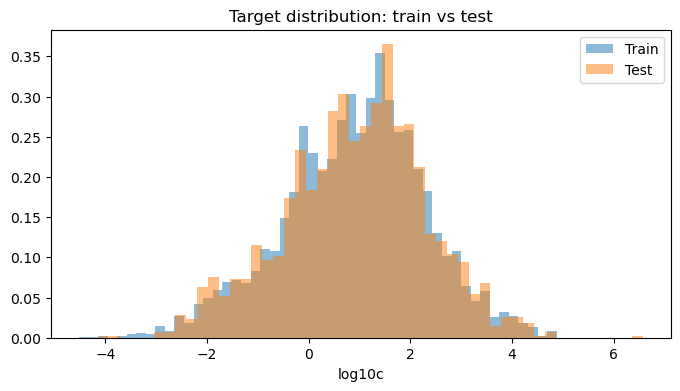

Train mean: 0.90, std: 1.40
Test mean:  0.91,  std: 1.40


In [23]:
from src.utils.plotting import plot_toxicity_distribution

plot_toxicity_distribution(train_dataset, test_dataset)

In [24]:
from torch_geometric.loader import DataLoader
# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(type(train_loader))

<class 'torch_geometric.loader.dataloader.DataLoader'>


# GNN

In [25]:
import torch
from src.model.modelMeta import TaxonomyEncoder
from src.model.modelAFP import AttentiveFP
from src.model.modelGCN import GCN
from src.model.modelFull import ToxicityModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model_tax = TaxonomyEncoder(config_tax).to(device)

model_gnn = AttentiveFP(
    in_channels=9,
    edge_dim=3,
    hidden_channels=64,
    num_layers=3,
    dropout=0.4
).to(device)

# model_gnn = GCN(
#     mol_dim=9,
#     hidden_dim=64,
#     output_dim=64
# )

model_full = ToxicityModel(model_gnn, model_tax, hidden_dim=64).to(device)

Device: cpu


### Training

Epoch 0: Train Loss = 1.7631, Val Loss = 1.5083
Epoch 10: Train Loss = 1.0812, Val Loss = 1.0867
Epoch 20: Train Loss = 0.9440, Val Loss = 1.0491
Epoch 30: Train Loss = 0.8789, Val Loss = 0.9033
Epoch 40: Train Loss = 0.7657, Val Loss = 0.8671
Epoch 50: Train Loss = 0.7167, Val Loss = 0.8379
Epoch 60: Train Loss = 0.6894, Val Loss = 0.7647
Epoch 70: Train Loss = 0.6501, Val Loss = 0.7642
Epoch 80: Train Loss = 0.6256, Val Loss = 0.7326
Epoch 90: Train Loss = 0.6092, Val Loss = 0.7137


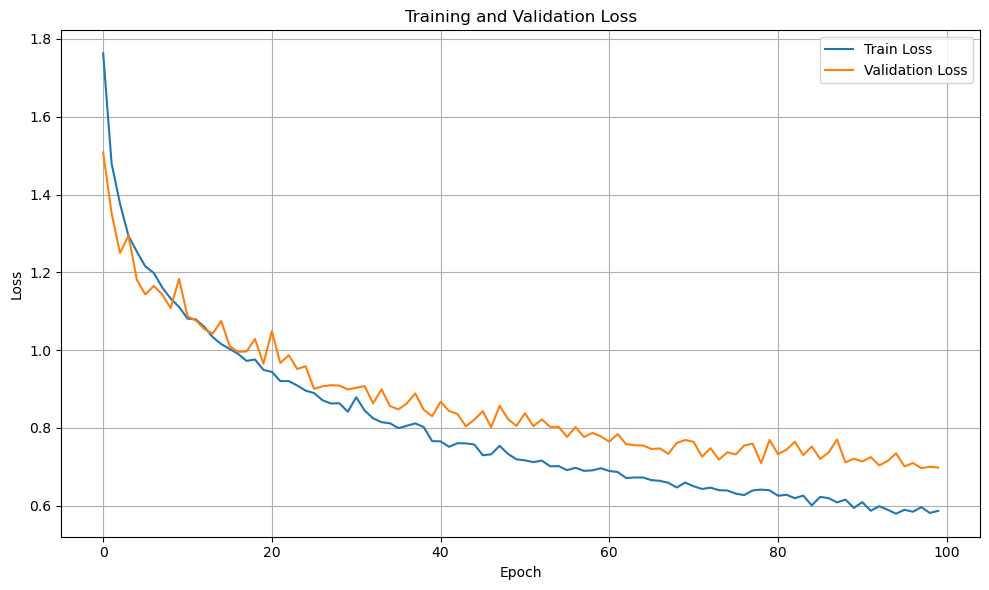

In [26]:
from src.model.eval import train
from src.utils.plotting import plot_training

model = model_full

# loss_fn = torch.nn.MSELoss()
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
# Halves the learning rate if validation loss doesn't improve for X epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=20, factor=0.5)

model, history = train(model, train_loader, test_loader, loss_fn=loss_fn, optimizer=optimizer, scheduler=scheduler, epochs=100, device=device)

plot_training(history)


In [27]:
from sklearn.metrics import r2_score

preds, targets = [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = model(batch)
        preds.extend(pred.squeeze().cpu().numpy())
        targets.extend(batch.y.cpu().numpy())

print(f"R²: {r2_score(targets, preds):.3f}")  # want this well above 0
# print(f"RMSE: {np.sqrt(mean_squared_error(targets, preds)):.3f}")

R²: 0.642


In [ ]:
from sklearn.metrics import r2_score
from src.utils.splitter import generate_scaffold

model.eval()
preds, targets, scaffolds = [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = model(batch).squeeze()
        preds.extend(pred.cpu().numpy())
        targets.extend(batch.y.cpu().numpy())
        scaffolds.extend(batch.smiles)

# Get scaffold for each test molecule
scaffold_list = [generate_scaffold(smi) for smi in scaffolds]

results_df = pd.DataFrame({
    "pred": preds,
    "actual": targets,
    "scaffold": scaffold_list
})

print(results_df.groupby("scaffold").apply(
    lambda g: pd.Series({
        "n": len(g),
        "r2": r2_score(g["actual"], g["pred"]) if len(g) > 1 else np.nan,
        "mean_error": (g["pred"] - g["actual"]).abs().mean()
    })
).sort_values("r2"))

                                     n            r2  mean_error
scaffold                                                        
c1ccc(CN2CC3CCCNC3C2)cc1           3.0 -1.488884e+13    0.459982
11709b21ba7e528a910d3a2a3933038b   3.0 -1.135696e+13    0.800811
O=C(CCc1ccccc1)c1ccc(N2CCOCC2)cc1  2.0 -5.999224e+04    1.143840
4e0d4b8ae61ebed9b5c92e5a53e49e9c   3.0 -1.425456e+04    0.603560
f2bd2a6c45b013463aed0bdf3f5b30c9   2.0 -7.539848e+03    0.508483
...                                ...           ...         ...
fc7a447d9d9ee5f24eca7d5db68dd0fa   1.0           NaN    0.204205
fcbc6f4c28867cf4e730c7ef81d5d006   1.0           NaN    0.162145
fd2a81dc2e73b38f8bcff19f3561cc17   1.0           NaN    0.899453
ff305f2b257fd747271a0ba348bd1b00   1.0           NaN    0.327423
n1n[n-]c(-c2nnn[n-]2)n1            1.0           NaN    0.043085

[688 rows x 3 columns]


/tmp/ipykernel_1920353/2622742773.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(results_df.groupby("scaffold").apply(


Text(0, 0.5, 'Predicted log10c')

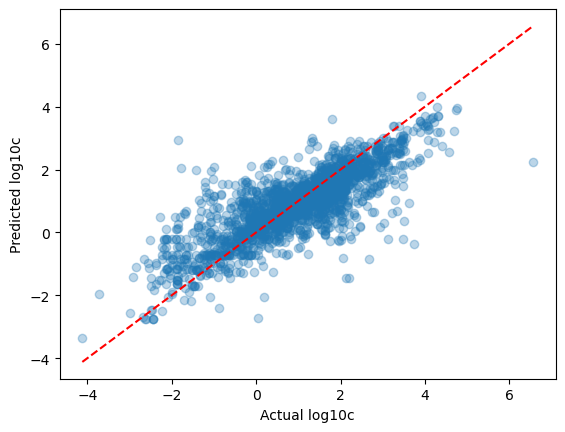

In [29]:
import matplotlib.pyplot as plt
plt.scatter(targets, preds, alpha=0.3)
plt.plot([min(targets), max(targets)], [min(targets), max(targets)], 'r--')
plt.xlabel("Actual log10c")
plt.ylabel("Predicted log10c")